# Full Pipeline Visualization Dashboard

This notebook visualizes all key outputs generated by `python main.py`.

It reads from:
- `data/processed/`
- `output/tables/`
- `output/figures/`


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)

ROOT = Path("..").resolve()
DATA_PROCESSED = ROOT / "data" / "processed"
TABLES = ROOT / "output" / "tables"
FIGURES = ROOT / "output" / "figures"

print("ROOT:", ROOT)
print("Processed exists:", DATA_PROCESSED.exists())
print("Tables exists:", TABLES.exists())
print("Figures exists:", FIGURES.exists())


ROOT: C:\Users\Michael\Code\credit-default-risk-modeling
Processed exists: True
Tables exists: True
Figures exists: True


In [2]:
def read_csv_safe(path):
    if not path.exists():
        print(f"Missing file: {path}")
        return pd.DataFrame()

    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        print(f"Empty file (no columns): {path}")
        return pd.DataFrame()
    except Exception as exc:
        print(f"Could not read {path}: {exc}")
        return pd.DataFrame()

panel = read_csv_safe(DATA_PROCESSED / "panel.csv")
factors = read_csv_safe(DATA_PROCESSED / "factors.csv")

summary_stats = read_csv_safe(TABLES / "summary_statistics.csv")
corr_table = read_csv_safe(TABLES / "factor_correlations.csv")
regression_table = read_csv_safe(TABLES / "regression_results.csv")
spread_corr = read_csv_safe(TABLES / "spread_correlation_matrix.csv")
pca_spreads = read_csv_safe(TABLES / "pca_spreads_explained_variance.csv")
pca_basis = read_csv_safe(TABLES / "pca_basis_explained_variance.csv")

for df in [panel, factors]:
    if not df.empty and "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("panel shape:", panel.shape)
print("factors shape:", factors.shape)


panel shape: (2016, 4)
factors shape: (252, 19)


## 1) Quick data health checks

In [3]:
if panel.empty:
    print("panel.csv not found.")
else:
    display(panel.head())
    cds_cov = panel.groupby("country")["cds"].apply(lambda s: s.notna().mean()).rename("cds_non_null_ratio")
    display(cds_cov)
    if cds_cov.mean() == 0:
        print("CDS coverage is 0: basis-based sections will be empty; use spread-only proxy outputs.")

if factors.empty:
    print("factors.csv not found.")
else:
    display(factors.head())


,date,country,yield,cds
0,2005-01-01,AT,3.564100,NaN
1,2005-01-01,BE,3.590000,NaN
2,2005-01-01,DE,3.564762,NaN
3,2005-01-01,ES,3.590952,NaN
4,2005-01-01,FI,3.600000,NaN


country
AT    0.619048
BE    0.619048
DE    0.809524
ES    0.821429
FI    0.619048
FR    0.829365
IT    0.821429
NL    0.619048
Name: cds_non_null_ratio, dtype: float64

,date,L_t_equal,L_t_proxy_spread_only,cds_pair_ratio,n_countries_l_t,n_countries_proxy,std_basis_t,mad_basis_t,range_basis_t,iqr_basis_t,std_spread_t,mad_spread_t,range_spread_t,iqr_spread_t,std_basis_proxy_t,mad_basis_proxy_t,range_basis_proxy_t,iqr_basis_proxy_t,avg_spread_t
0,2005-01-01,NaN,0.034388,0.0,0,7,NaN,NaN,NaN,NaN,0.051560,0.010000,0.153,0.023426,0.051560,0.010000,0.153,0.023426,0.034388
1,2005-02-01,NaN,0.040136,0.0,0,7,NaN,NaN,NaN,NaN,0.045349,0.022700,0.131,0.033675,0.045349,0.022700,0.131,0.033675,0.040136
2,2005-03-01,NaN,0.045485,0.0,0,7,NaN,NaN,NaN,NaN,0.048913,0.026571,0.148,0.043850,0.048913,0.026571,0.148,0.043850,0.045485
3,2005-04-01,NaN,0.061303,0.0,0,7,NaN,NaN,NaN,NaN,0.062116,0.032786,0.176,0.066750,0.062116,0.032786,0.176,0.066750,0.061303
4,2005-05-01,NaN,0.092306,0.0,0,7,NaN,NaN,NaN,NaN,0.082519,0.050000,0.249,0.079209,0.082519,0.050000,0.249,0.079209,0.092306


## 2) Main Fragmentation Factor (Report Figure)

This figure focuses on the **CDS-adjusted cross-country fragmentation factor** and its dispersion counterpart.

- `L_t_equal`: cross-country average of CDS-adjusted residual basis vs Germany
- `std_basis_t`: cross-sectional dispersion of that basis

Interpretation:
- high `L_t_equal` = broad non-default wedge relative to Germany
- high `std_basis_t` = heterogeneous fragmentation across issuers

L_t_equal sample: 2009-01-01 to 2025-12-01 (n=204)


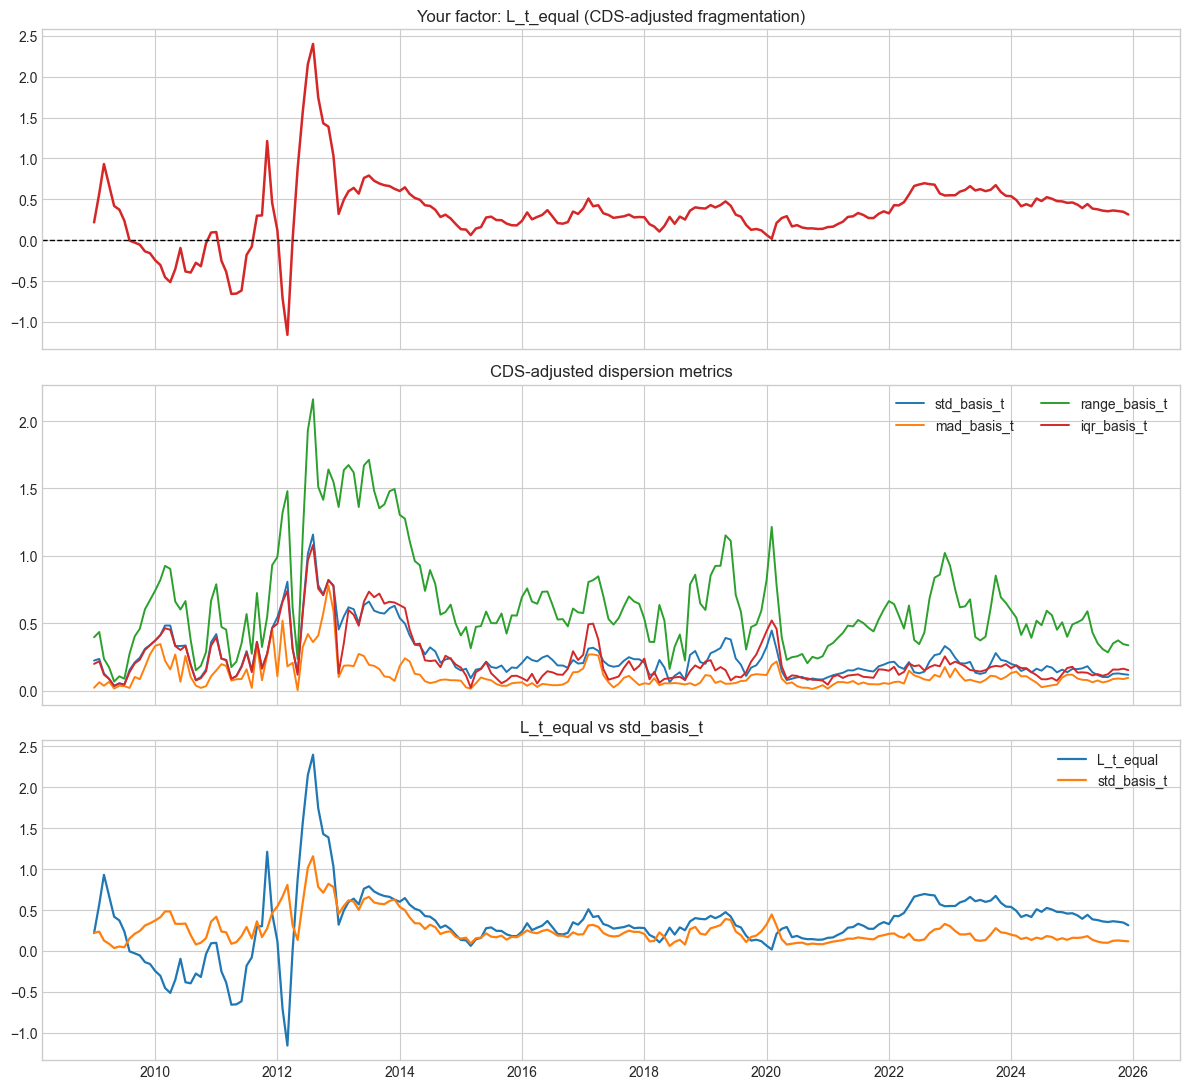

In [4]:
if factors.empty:
    print("No factor data available.")
else:
    # Keep only dates where your CDS-adjusted factor exists.
    d = factors.copy()
    d = d[d["L_t_equal"].notna()].copy() if "L_t_equal" in d.columns else pd.DataFrame()

    if d.empty:
        print("L_t_equal is empty in this run.")
    else:
        print(f"L_t_equal sample: {d['date'].min().date()} to {d['date'].max().date()} (n={len(d)})")

        fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

        axes[0].plot(d["date"], d["L_t_equal"], color="tab:red", lw=1.8)
        axes[0].axhline(0, color="black", ls="--", lw=1)
        axes[0].set_title("Your factor: L_t_equal (CDS-adjusted fragmentation)")

        disp_cols = [c for c in ["std_basis_t", "mad_basis_t", "range_basis_t", "iqr_basis_t"] if c in d.columns]
        for c in disp_cols:
            axes[1].plot(d["date"], d[c], label=c, lw=1.4)
        axes[1].set_title("CDS-adjusted dispersion metrics")
        if disp_cols:
            axes[1].legend(ncol=2)

        if "std_basis_t" in d.columns:
            axes[2].plot(d["date"], d["L_t_equal"], label="L_t_equal", lw=1.6)
            axes[2].plot(d["date"], d["std_basis_t"], label="std_basis_t", lw=1.6)
            axes[2].set_title("L_t_equal vs std_basis_t")
            axes[2].legend()

        plt.tight_layout()
        plt.show()


## 3) Cross-Country Decomposition Panels (Report Figures)

These panels show the building blocks of the factor construction:

1. Raw sovereign spreads vs Germany
2. CDS-adjusted yields, `r_tilde = yield - cds`
3. Residual basis vs Germany, `basis = r_tilde_i - r_tilde_DE`

Economic takeaway:
- if markets were frictionless/integrated, panel (2) would align tightly across countries and panel (3) would remain near zero.

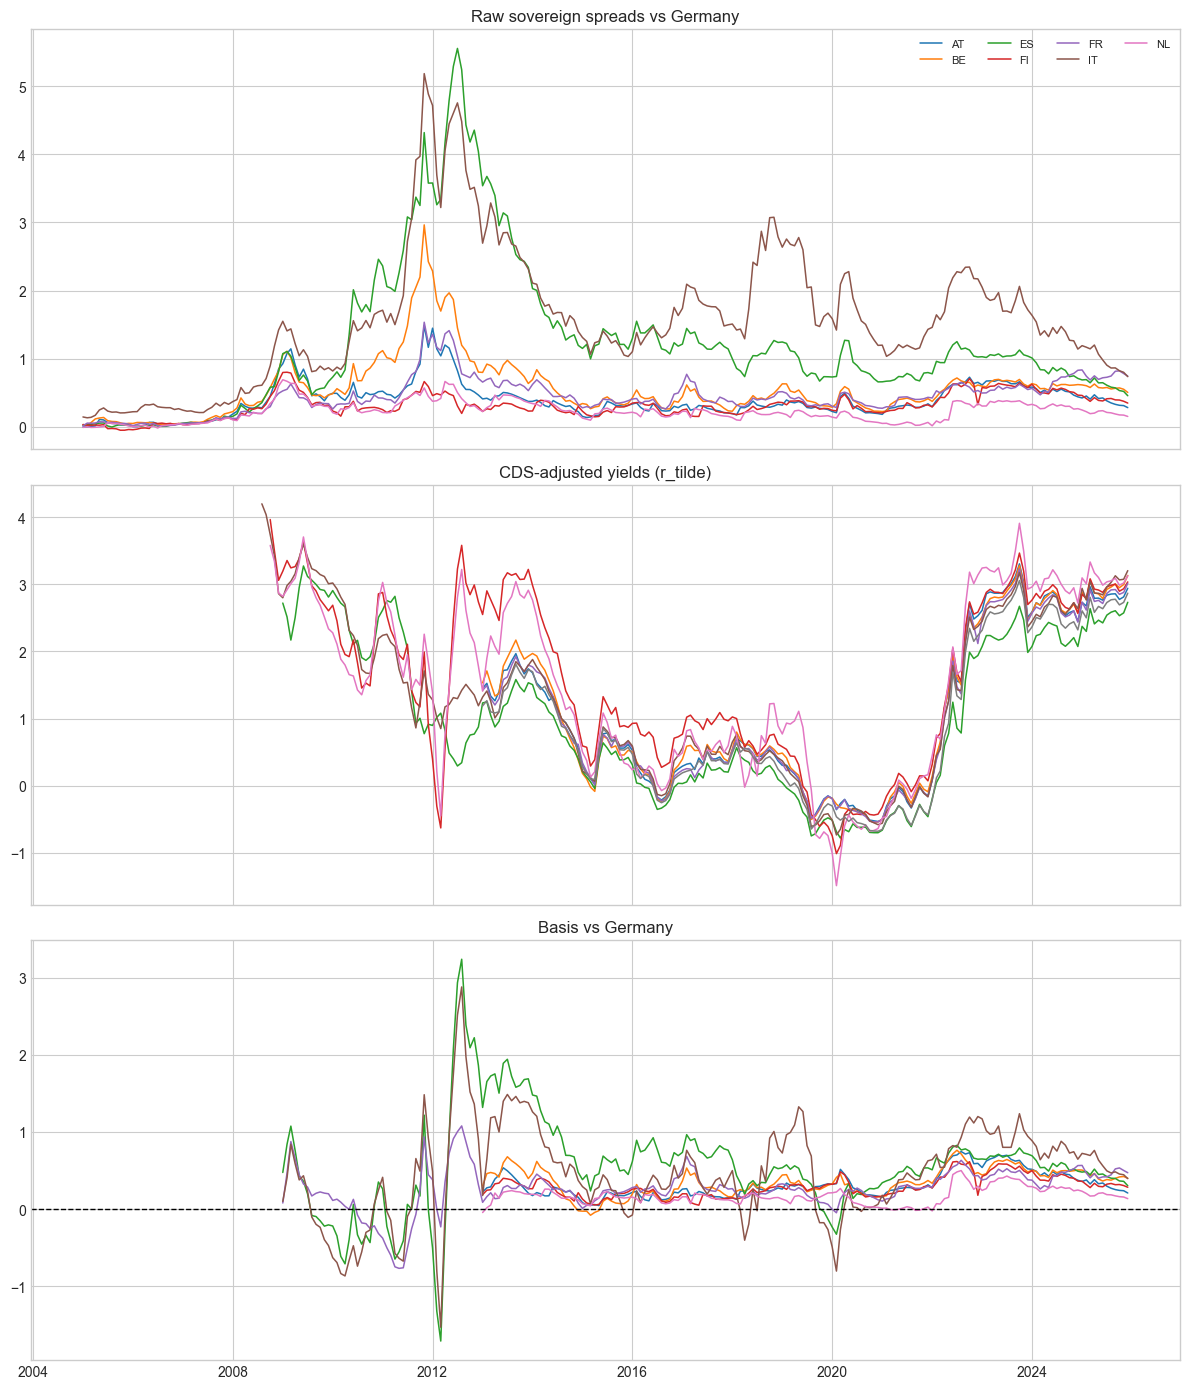

In [5]:
if panel.empty:
    print("panel data missing")
else:
    d = panel.copy()
    de = d[d["country"] == "DE"][["date", "yield", "cds"]].rename(columns={"yield": "yield_de", "cds": "cds_de"})
    d = d.merge(de, on="date", how="inner")
    d["spread_vs_de"] = d["yield"] - d["yield_de"]
    d["r_tilde"] = d["yield"] - d["cds"]
    d["r_tilde_de"] = d["yield_de"] - d["cds_de"]
    d["basis"] = d["r_tilde"] - d["r_tilde_de"]

    non_de = d[d["country"] != "DE"].copy()

    fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

    for c, g in non_de.groupby("country"):
        axes[0].plot(g["date"], g["spread_vs_de"], lw=1.1, label=c)
    axes[0].set_title("Raw sovereign spreads vs Germany")
    axes[0].legend(ncol=4, fontsize=8)

    for c, g in d.groupby("country"):
        axes[1].plot(g["date"], g["r_tilde"], lw=1.1, label=c)
    axes[1].set_title("CDS-adjusted yields (r_tilde)")

    for c, g in non_de.groupby("country"):
        axes[2].plot(g["date"], g["basis"], lw=1.1, label=c)
    axes[2].axhline(0, color="black", ls="--", lw=1)
    axes[2].set_title("Basis vs Germany")

    plt.tight_layout()
    plt.show()


## 4) Tables: summary stats, correlations, regressions, PCA explained variance

In [6]:
print("Summary statistics")
display(summary_stats.head(50))

print("Factor correlations")
display(corr_table.head(50))

print("Regression outputs")
display(regression_table.head(100))

print("Spread correlation matrix")
display(spread_corr.head(50))

print("PCA explained variance: spreads")
display(pca_spreads)

print("PCA explained variance: basis")
display(pca_basis)


Summary statistics


,series,count,mean,std,min,25%,50%,75%,max
0,L_t_equal,204.0,0.336800,0.407572,-1.157545,0.181917,0.320841,0.497649,2.399356
1,L_t_proxy_spread_only,252.0,0.673310,0.427189,0.034388,0.481761,0.629966,0.820758,2.389179
2,cds_pair_ratio,252.0,0.700680,0.404636,0.000000,0.428571,1.000000,1.000000,1.000000
3,std_basis_t,204.0,0.256629,0.179872,0.035237,0.146398,0.201902,0.303296,1.158120
4,std_basis_proxy_t,252.0,0.543214,0.411053,0.045349,0.249305,0.495068,0.651888,2.155704
5,mad_basis_t,204.0,0.113243,0.109035,0.002676,0.052207,0.077293,0.119162,0.780935
6,range_basis_t,204.0,0.655593,0.380494,0.067119,0.407555,0.569884,0.783775,2.161286
7,iqr_basis_t,204.0,0.233797,0.192114,0.021648,0.112336,0.165456,0.265991,1.080643
8,avg_spread_t,252.0,0.673310,0.427189,0.034388,0.481761,0.629966,0.820758,2.389179


Factor correlations


,index,L_t_equal,L_t_proxy_spread_only,std_basis_t,std_basis_proxy_t,avg_spread_t,PC1,spread_PC1
0,L_t_equal,1.000000,0.413916,0.403484,0.437770,0.413916,0.923269,0.379120
1,L_t_proxy_spread_only,0.413916,1.000000,0.628614,0.926996,1.000000,0.629090,0.962844
2,std_basis_t,0.403484,0.628614,1.000000,0.713814,0.628614,0.272346,0.479751
3,std_basis_proxy_t,0.437770,0.926996,0.713814,1.000000,0.926996,0.144967,0.795426
4,avg_spread_t,0.413916,1.000000,0.628614,0.926996,1.000000,0.629090,0.962844
5,PC1,0.923269,0.629090,0.272346,0.144967,0.629090,1.000000,0.890811
6,spread_PC1,0.379120,0.962844,0.479751,0.795426,0.962844,0.890811,1.000000


Regression outputs


...

,country,AT,BE,ES,FI,FR,IT,NL
0,AT,1.000000,0.870092,0.612753,0.819029,0.813074,0.687466,0.849257
1,BE,0.870092,1.000000,0.809093,0.585346,0.847865,0.802970,0.757208
2,ES,0.612753,0.809093,1.000000,0.315163,0.734841,0.875816,0.632811
3,FI,0.819029,0.585346,0.315163,1.000000,0.684998,0.494361,0.750359
4,FR,0.813074,0.847865,0.734841,0.684998,1.000000,0.797414,0.710974
5,IT,0.687466,0.802970,0.875816,0.494361,0.797414,1.000000,0.633127
6,NL,0.849257,0.757208,0.632811,0.750359,0.710974,0.633127,1.000000


PCA explained variance: spreads


,component,explained_ratio
0,PC1,0.762007
1,PC2,0.130157
2,PC3,0.040979
3,PC4,0.030811
4,PC5,0.019484
5,PC6,0.009424
6,PC7,0.007138


PCA explained variance: basis


,component,explained_ratio,source
0,PC1,0.624379,cds_adjusted_basis
1,PC2,0.185910,cds_adjusted_basis
2,PC3,0.074909,cds_adjusted_basis
3,PC4,0.053391,cds_adjusted_basis
4,PC5,0.034012,cds_adjusted_basis
5,PC6,0.014785,cds_adjusted_basis
6,PC7,0.012614,cds_adjusted_basis


## 5) Display all saved figures from `output/figures`

Found 9 figure(s)
01_spreads_vs_de.png


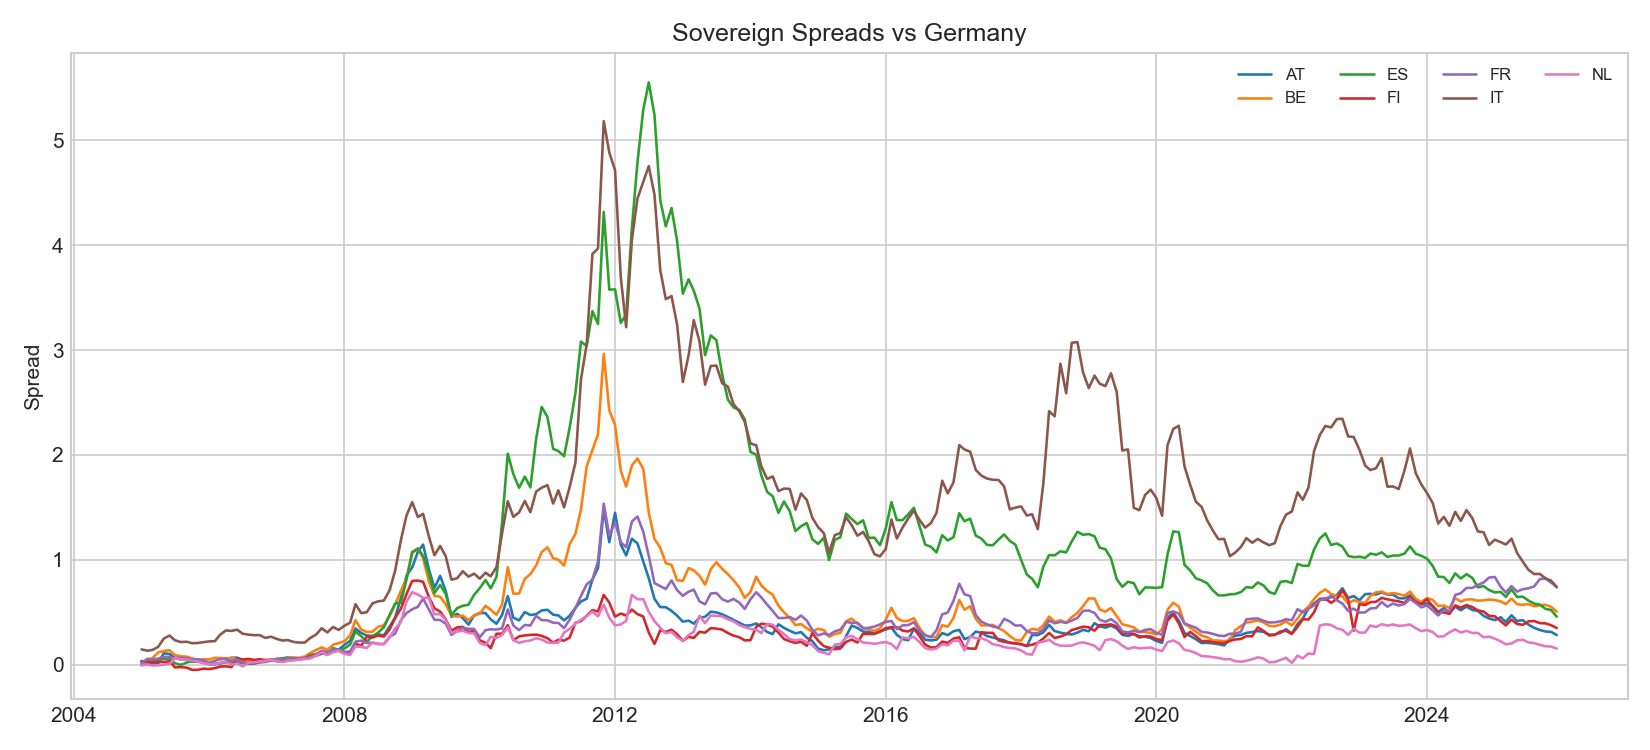

02_cds_adjusted_yields.png


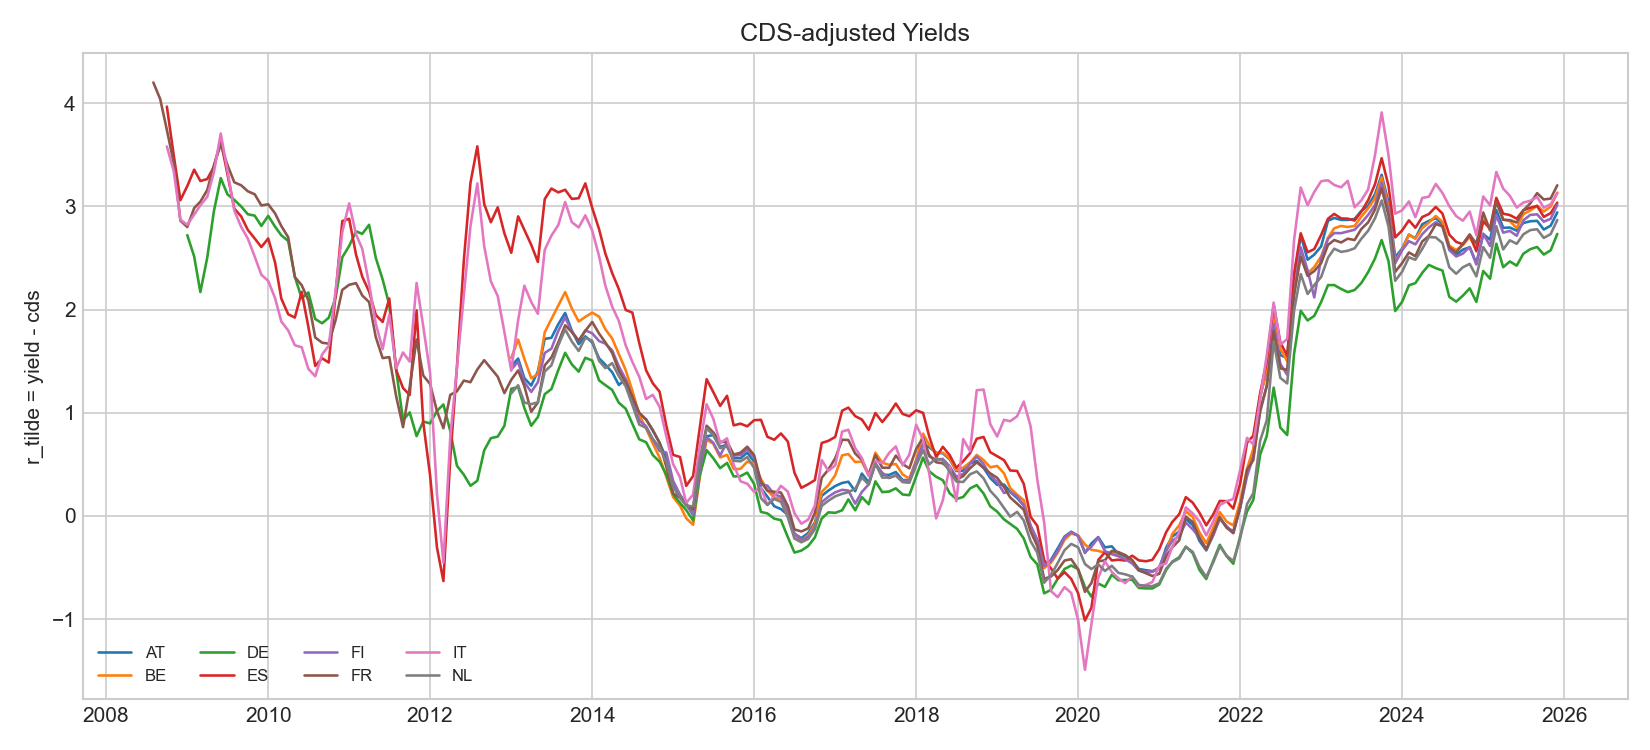

03_basis_by_country.png


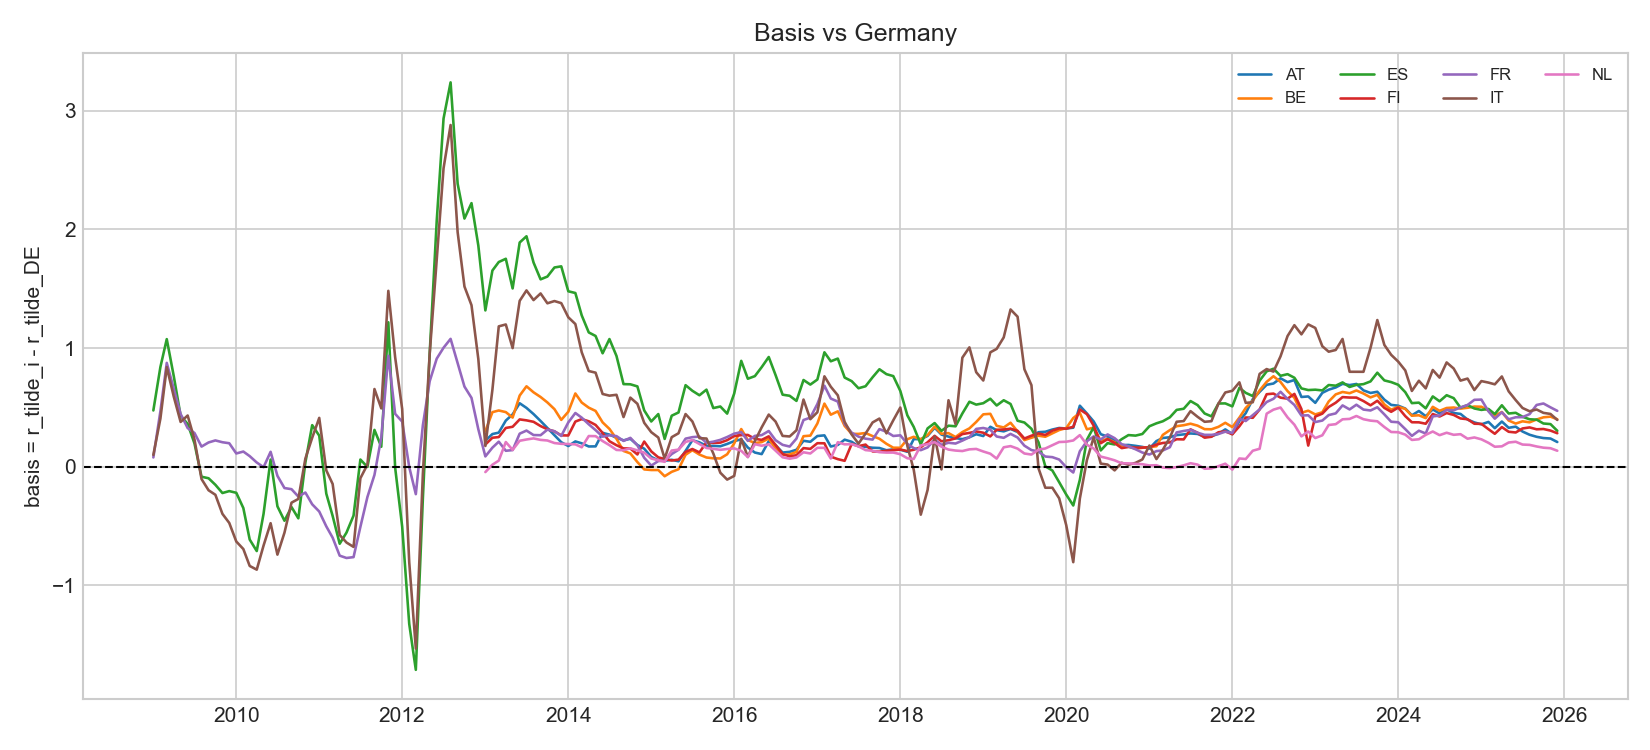

04_L_t.png


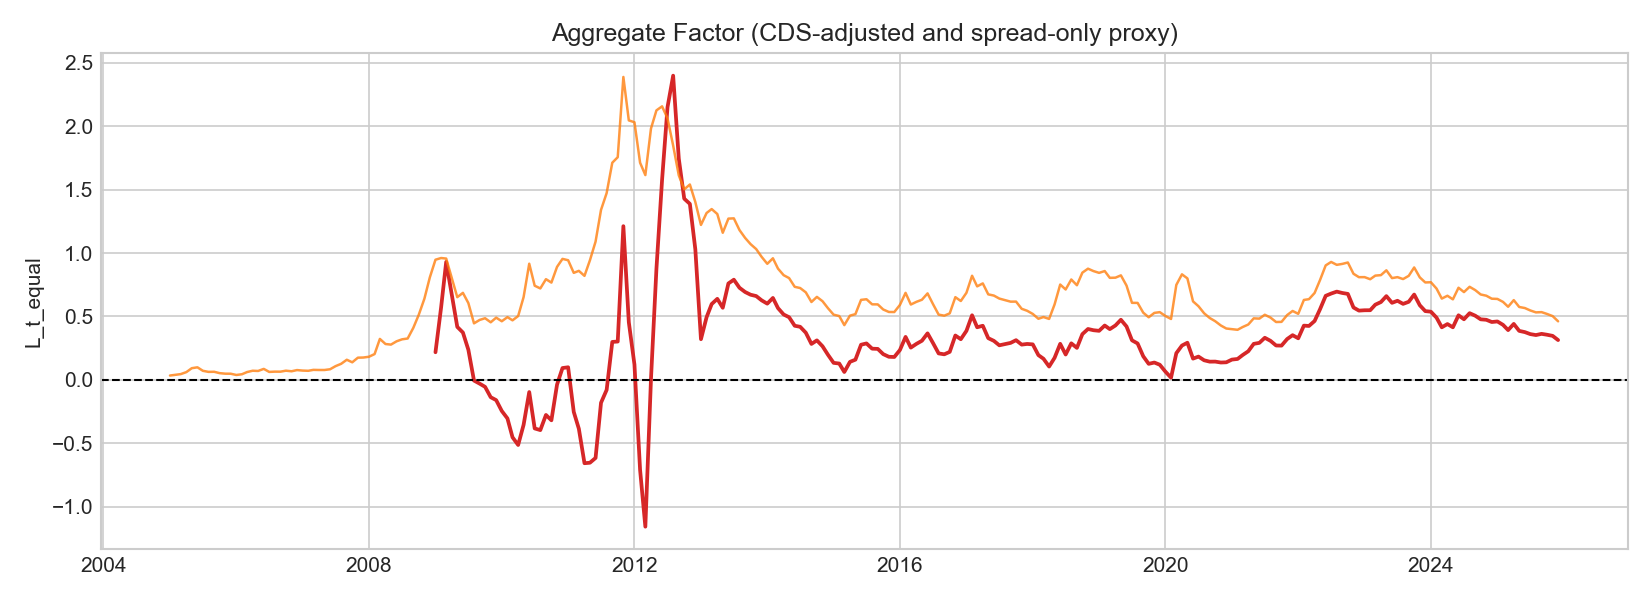

05_dispersion_metrics_basis.png


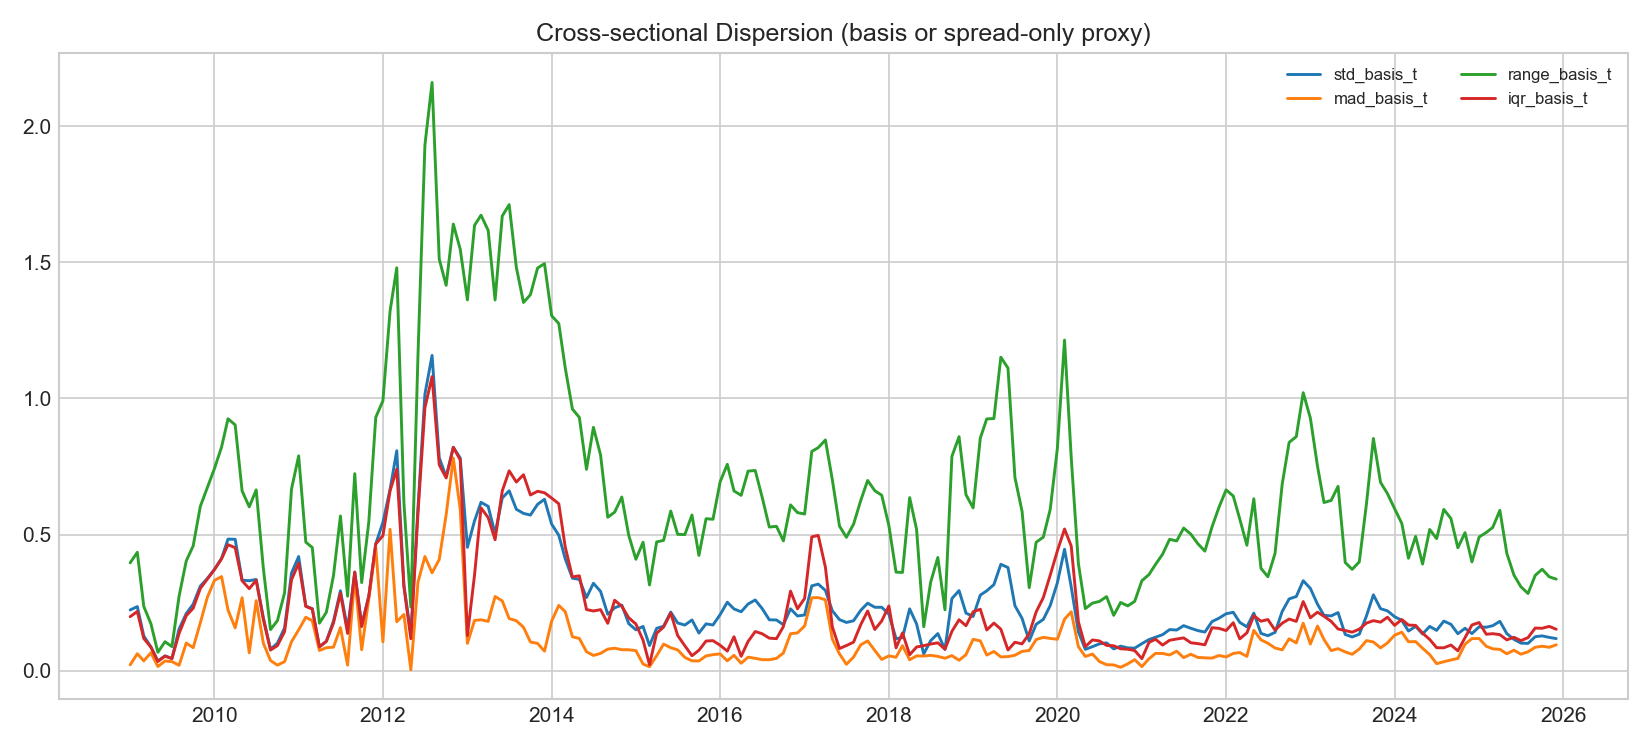

06_pca_scree_spreads.png


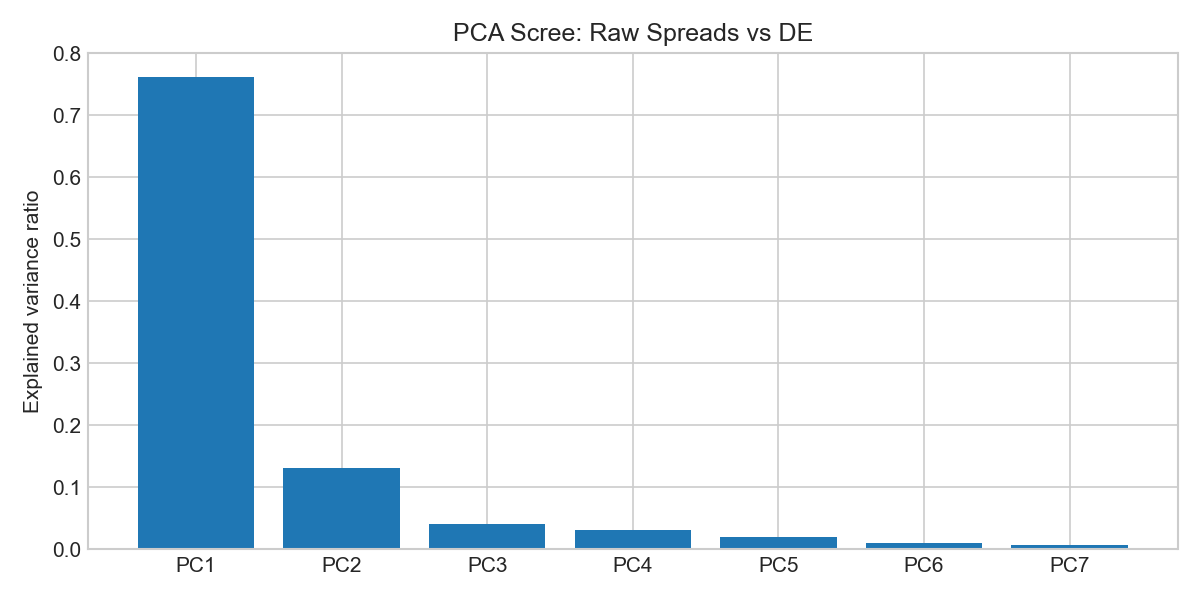

07_pca_scree_basis.png


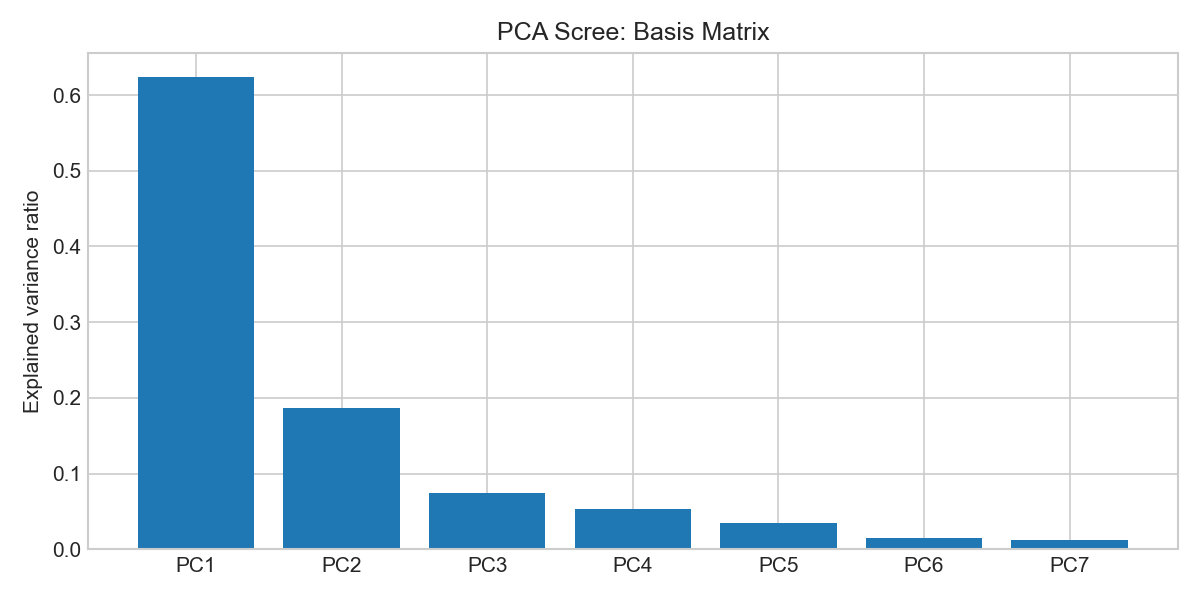

08_correlation_heatmap.png


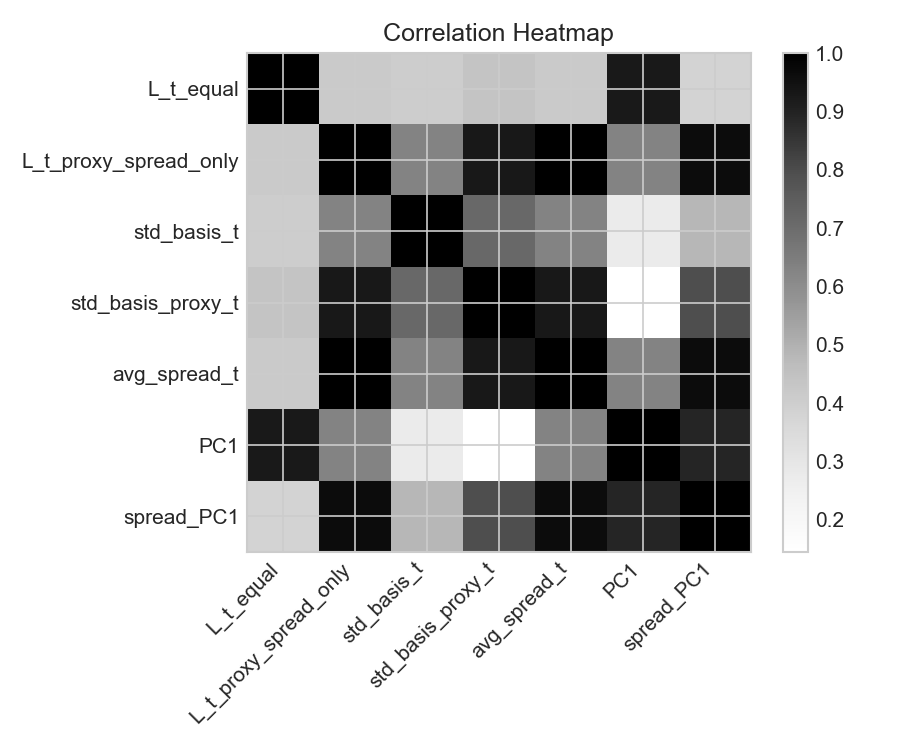

09_L_t_vs_std_basis.png


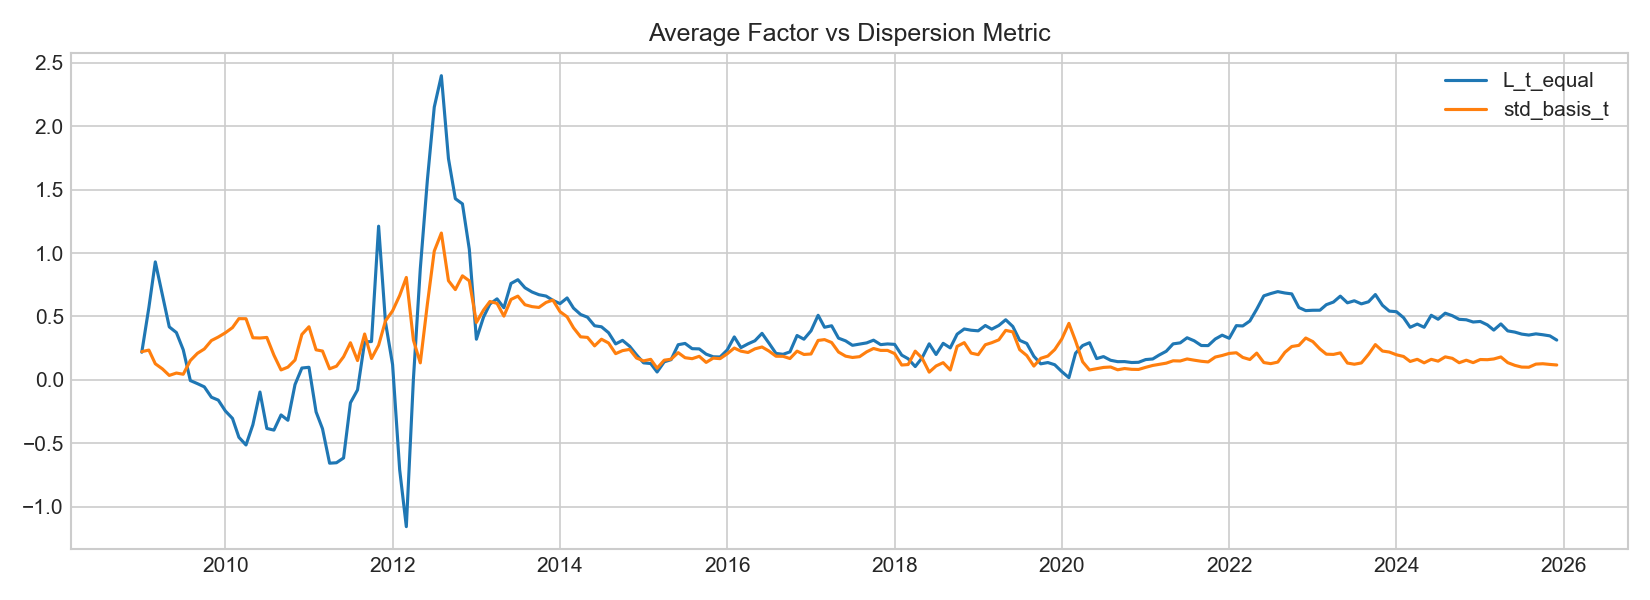

In [7]:
from IPython.display import Image, display

pngs = sorted(FIGURES.glob("*.png"))
print(f"Found {len(pngs)} figure(s)")
for p in pngs:
    print(p.name)
    display(Image(filename=str(p)))


## 6) Interpretation helper (quick checklist)

- If `L_t_equal` and `std_basis_t` spike together, fragmentation is broad and common.
- If `std_basis_t` spikes while `L_t_equal` is stable, stress is heterogeneous across countries.
- If basis PCA PC1 has high explained variance, there is a dominant common residual force.
- If CDS coverage ratios are low, treat basis results as preliminary until CDS anchors are filled.


## 7) CDS Input Validation (Actual Market Units)

These charts validate CDS inputs in **basis points (bps)**, the market convention.

- raw CDS levels by country (in bps)
- CDS differentials vs Germany (in bps)

Note: the pipeline converts CDS to percent points internally for arithmetic with yields. This section converts back to bps for reporting.

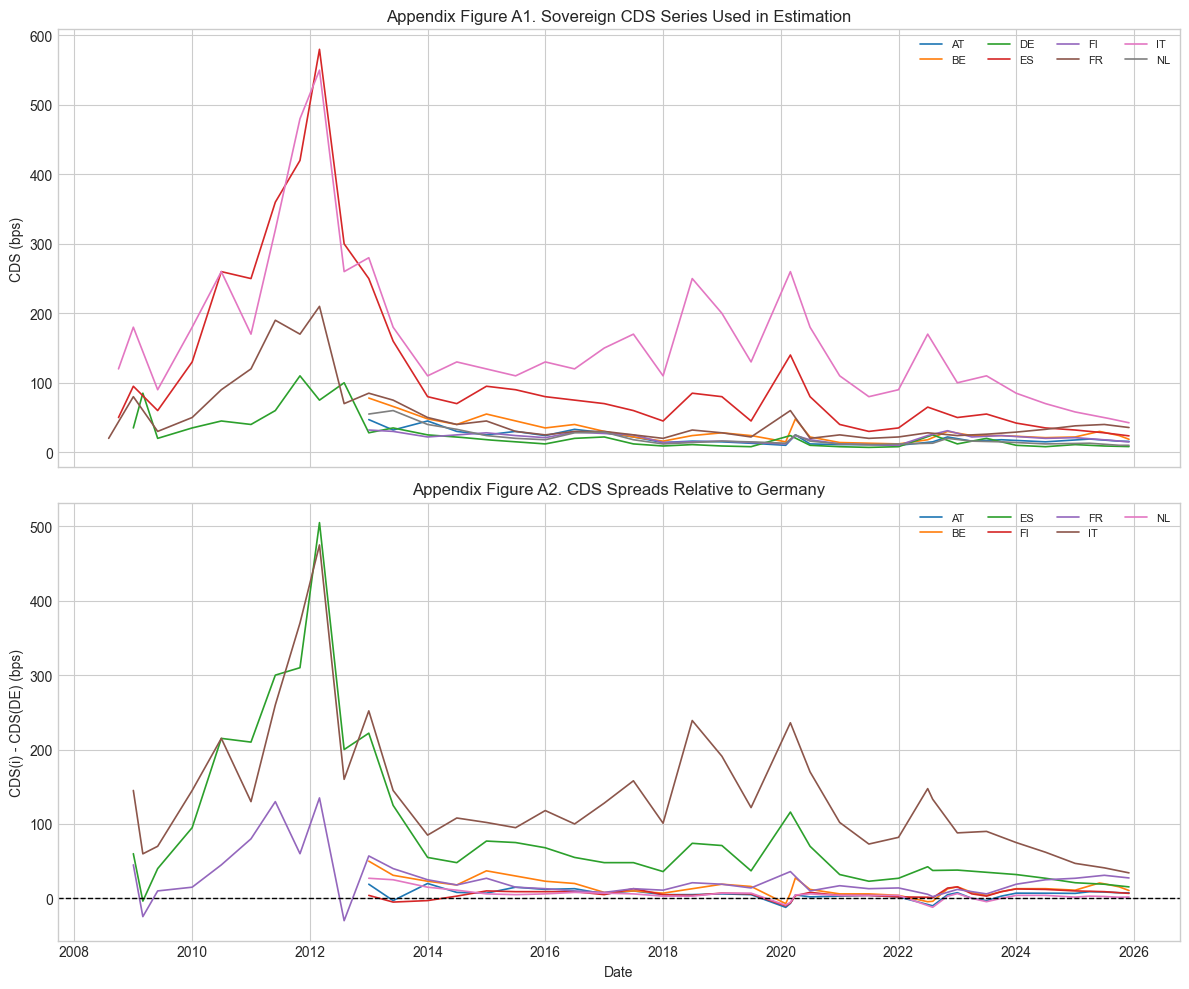

In [8]:
if panel.empty:
    print("panel data missing")
else:
    cds_df = panel[["date", "country", "cds"]].copy()
    cds_df = cds_df.dropna(subset=["cds"]).sort_values(["date", "country"])

    if cds_df.empty:
        print("No CDS values available in current panel.")
    else:
        cds_df["cds_bps"] = 100.0 * cds_df["cds"]

        fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

        # A) Raw CDS levels in bps
        for c, g in cds_df.groupby("country"):
            axes[0].plot(g["date"], g["cds_bps"], lw=1.2, label=c)
        axes[0].set_title("Appendix Figure A1. Sovereign CDS Series Used in Estimation")
        axes[0].set_ylabel("CDS (bps)")
        axes[0].legend(ncol=4, fontsize=8)

        # B) CDS relative to Germany (bps)
        de = cds_df[cds_df["country"] == "DE"][["date", "cds_bps"]].rename(columns={"cds_bps": "cds_de_bps"})
        rel = cds_df.merge(de, on="date", how="inner")
        rel = rel[rel["country"] != "DE"].copy()
        rel["cds_spread_vs_de_bps"] = rel["cds_bps"] - rel["cds_de_bps"]

        if rel.empty:
            axes[1].text(0.02, 0.5, "No Germany-overlap dates for CDS spread comparison", transform=axes[1].transAxes)
        else:
            for c, g in rel.groupby("country"):
                axes[1].plot(g["date"], g["cds_spread_vs_de_bps"], lw=1.2, label=c)
            axes[1].axhline(0, color="black", ls="--", lw=1)
            axes[1].set_title("Appendix Figure A2. CDS Spreads Relative to Germany")
            axes[1].set_ylabel("CDS(i) - CDS(DE) (bps)")
            axes[1].legend(ncol=4, fontsize=8)

        axes[1].set_xlabel("Date")
        plt.tight_layout()
        plt.show()


## 8) Does the Liquidity-Basis Factor Explain Spreads?

This section runs simple paper-style explanatory regressions on the CDS-identified sample.

Core checks:
- `avg_spread_t ~ L_t_equal`
- `avg_spread_t ~ L_t_equal + std_basis_t`
- `std_basis_t ~ L_t_equal`

Interpretation:
- strong fit in the first model suggests the factor captures common spread dynamics
- added incremental fit from `std_basis_t` indicates dispersion provides extra information

Regression sample: 2009-01-01 to 2025-12-01 (n=204)


,term,coef,t,p,model,r2,nobs
0,const,0.666751,21.395805,8.096658e-54,avg_spread_t ~ L_t_equal,0.171326,204
1,L_t_equal,0.381448,6.462425,7.565087e-10,avg_spread_t ~ L_t_equal,0.171326,204
2,const,0.440332,12.446660,9.728838e-27,avg_spread_t ~ L_t_equal + std_basis_t,0.425840,204
3,L_t_equal,0.176430,3.277521,1.233791e-03,avg_spread_t ~ L_t_equal + std_basis_t,0.425840,204
4,std_basis_t,1.151345,9.439251,9.697834e-18,avg_spread_t ~ L_t_equal + std_basis_t,0.425840,204
5,const,0.196656,13.110310,8.119286e-29,std_basis_t ~ L_t_equal,0.162800,204
6,L_t_equal,0.178068,6.267405,2.179373e-09,std_basis_t ~ L_t_equal,0.162800,204


,model,r2,adj_r2,nobs
0,Model 1,0.171326,0.167224,204
1,Model 2,0.425840,0.420127,204
2,Model 3,0.162800,0.158655,204


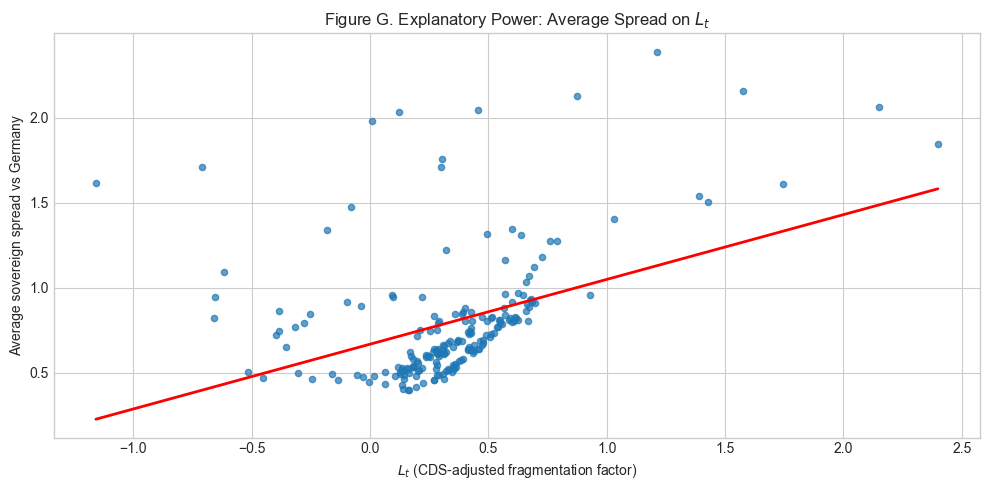

In [9]:
import statsmodels.api as sm

if factors.empty:
    print("No factor data available.")
else:
    d = factors.copy()
    d = d[["date", "L_t_equal", "std_basis_t", "avg_spread_t"]].dropna()

    if d.empty:
        print("No CDS-identified sample for regression.")
    else:
        print(f"Regression sample: {d['date'].min().date()} to {d['date'].max().date()} (n={len(d)})")

        def run_ols(df, y, xs):
            X = sm.add_constant(df[xs], has_constant="add")
            m = sm.OLS(df[y], X).fit()
            out = pd.DataFrame({
                "term": m.params.index,
                "coef": m.params.values,
                "t": m.tvalues.values,
                "p": m.pvalues.values,
            })
            out["model"] = f"{y} ~ {' + '.join(xs)}"
            out["r2"] = m.rsquared
            out["nobs"] = int(m.nobs)
            return out, m

        tables = []
        models = []

        t1, m1 = run_ols(d, "avg_spread_t", ["L_t_equal"])
        tables.append(t1); models.append(("Model 1", m1))

        t2, m2 = run_ols(d, "avg_spread_t", ["L_t_equal", "std_basis_t"])
        tables.append(t2); models.append(("Model 2", m2))

        t3, m3 = run_ols(d, "std_basis_t", ["L_t_equal"])
        tables.append(t3); models.append(("Model 3", m3))

        reg_table = pd.concat(tables, ignore_index=True)
        display(reg_table)

        r2_table = pd.DataFrame({
            "model": [name for name, _ in models],
            "r2": [m.rsquared for _, m in models],
            "adj_r2": [m.rsquared_adj for _, m in models],
            "nobs": [int(m.nobs) for _, m in models],
        })
        display(r2_table)

        # Visual fit for Model 1
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.scatter(d["L_t_equal"], d["avg_spread_t"], alpha=0.7, s=20)
        x = np.linspace(d["L_t_equal"].min(), d["L_t_equal"].max(), 100)
        intercept = m1.params.get("const", 0.0)
        slope = m1.params.get("L_t_equal", 0.0)
        y = intercept + slope * x
        ax.plot(x, y, color="red", lw=2)
        ax.set_title("Figure G. Explanatory Power: Average Spread on $L_t$")
        ax.set_xlabel("$L_t$ (CDS-adjusted fragmentation factor)")
        ax.set_ylabel("Average sovereign spread vs Germany")
        plt.tight_layout()
        plt.show()


## 9) Report Figure Selection (Main Text vs Appendix)

Use this section to keep only publication-relevant plots.

### Main text (recommended)
- `Figure A`: Cross-country CDS-adjusted fragmentation factor ($L_t$)
- `Figure B`: Dispersion of CDS-adjusted basis (`std_basis_t`, etc.)
- `Figure C`: $L_t$ vs `std_basis_t` (prefer standardized view)
- `Figure D`: Sovereign spreads vs Germany (stylized fact)
- `Figure G`: Explanatory power of $L_t$ for average spread

### Appendix (recommended)
- CDS input validation plots (A1/A2)
- PCA scree and correlation heatmap
- Additional robustness / proxy plots


In [ ]:
from IPython.display import Image, display

# Map existing saved figures to report buckets.
main_text_files = [
    "01_spreads_vs_de.png",          # Figure D
    "04_L_t.png",                    # Figure A
    "05_dispersion_metrics_basis.png",  # Figure B
    "09_L_t_vs_std_basis.png",       # Figure C
]

appendix_files = [
    "02_cds_adjusted_yields.png",
    "03_basis_by_country.png",
    "06_pca_scree_spreads.png",
    "07_pca_scree_basis.png",
    "08_correlation_heatmap.png",
]

print("Main text figures")
for fn in main_text_files:
    p = FIGURES / fn
    if p.exists():
        print("-", fn)
        display(Image(filename=str(p)))
    else:
        print("- missing:", fn)

print("\nAppendix figures")
for fn in appendix_files:
    p = FIGURES / fn
    if p.exists():
        print("-", fn)
        display(Image(filename=str(p)))
    else:
        print("- missing:", fn)
